# PUAD: Picturable and Unpicturable Anomaly Detection

This notebook implements the PUAD logic on top of a trained EfficientAD model. 
It uses the pre-trained Teacher and Student networks to detect both local anomalies (scratches, structural defects) and logical anomalies (missing components) using Mahalanobis distance on global feature vectors.

NOTE: To choose the category you want to run the test upon, change the "dataset_name" variable in configurations in 4th step (Execution Setup)

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score
from typing import Dict, Union, Tuple, List
from tqdm import tqdm
import os

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True 
    print("cuDNN benchmark enabled for faster inference")

Using device: cuda
cuDNN benchmark enabled for faster inference


## 1. Model Architectures


In [32]:
class PDN_S(nn.Module):
    """Patch Description Network - Small"""
    def __init__(self, out_channels: int = 384, padding: bool = False):
        super().__init__()
        self.padding_mode = padding
        self.conv1 = nn.Conv2d(3, 128, kernel_size=4, stride=1, padding=3)
        self.avgpool1 = nn.AvgPool2d(kernel_size=2, stride=2, padding=1)
        
        self.conv2 = nn.Conv2d(128, 256, kernel_size=4, stride=1, padding=3)
        self.avgpool2 = nn.AvgPool2d(kernel_size=2, stride=2, padding=1)
        
        self.conv3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(256, out_channels, kernel_size=4, stride=1, padding=0)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.avgpool1(x)
        x = F.relu(self.conv2(x))
        x = self.avgpool2(x)
        x = F.relu(self.conv3(x))
        x = self.conv4(x)
        return x


class AutoEncoder(nn.Module):
    """AutoEncoder"""
    def __init__(self, out_channels: int = 384, img_size: int = 256, padding: bool = False):
        super().__init__()
        self.out_channels = out_channels
        self.img_size = img_size
        # Encoder
        self.enc_conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 32, kernel_size=4, stride=2, padding=1)
        self.enc_conv3 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.enc_conv4 = nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1)
        self.enc_conv5 = nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1)
        self.enc_conv6 = nn.Conv2d(64, 64, kernel_size=8, stride=1, padding=0)
        # Decoder
        self.dec_conv1 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout1 = nn.Dropout(0.2)
        self.dec_conv2 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout2 = nn.Dropout(0.2)
        self.dec_conv3 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout3 = nn.Dropout(0.2)
        self.dec_conv4 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout4 = nn.Dropout(0.2)
        self.dec_conv5 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout5 = nn.Dropout(0.2)
        self.dec_conv6 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=1, padding=2)
        self.dec_dropout6 = nn.Dropout(0.2)
        self.dec_conv7 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.dec_conv8 = nn.Conv2d(64, out_channels, kernel_size=3, stride=1, padding=1)
        
    def forward(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = F.relu(self.enc_conv3(x))
        x = F.relu(self.enc_conv4(x))
        x = F.relu(self.enc_conv5(x))
        x = self.enc_conv6(x)
        x = F.interpolate(x, size=(3, 3), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv1(x))
        x = self.dec_dropout1(x)
        x = F.interpolate(x, size=(8, 8), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv2(x))
        x = self.dec_dropout2(x)
        x = F.interpolate(x, size=(15, 15), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv3(x))
        x = self.dec_dropout3(x)
        x = F.interpolate(x, size=(32, 32), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv4(x))
        x = self.dec_dropout4(x)
        x = F.interpolate(x, size=(63, 63), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv5(x))
        x = self.dec_dropout5(x)
        x = F.interpolate(x, size=(127, 127), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv6(x))
        x = self.dec_dropout6(x)
        x = F.interpolate(x, size=(64, 64), mode='bilinear', align_corners=False)
        x = F.relu(self.dec_conv7(x))
        x = self.dec_conv8(x)
        return x

## 2. Helper Classes
Dataset loader and Inference Wrapper to handle model loading and running.

In [33]:
class NormalDataset(Dataset):
    """Simple Dataset loader for inference"""
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.img_paths = list(self.img_dir.glob('*'))
        self.img_paths = [p for p in self.img_paths if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]
        
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

class EfficientADInference:
    def __init__(self, config):
        self.device = config['device']
        self.out_channels = config['out_channels']
        self.img_size = config['img_size']
        
        self.teacher = PDN_S(out_channels=self.out_channels).to(self.device)
        self.student = PDN_S(out_channels=self.out_channels*2).to(self.device)
        self.autoencoder = AutoEncoder(
            out_channels=self.out_channels, 
            img_size=self.img_size
        ).to(self.device)
        
        self._load_weights(config['teacher_path'], config['student_path'], config['autoencoder_path'])
        
        #load normalization parameters
        self.mu = torch.load(os.path.join(config['model_dir'], 'mu.pt')).to(self.device)
        self.sigma = torch.load(os.path.join(config['model_dir'], 'sigma.pt')).to(self.device)
        
        quantile = torch.load(os.path.join(config['model_dir'], 'quantile.pt'))
        self.q_a_student = quantile['q_a_student'].to(self.device)
        self.q_b_student = quantile['q_b_student'].to(self.device)
        self.q_a_autoencoder = quantile['q_a_autoencoder'].to(self.device)
        self.q_b_autoencoder = quantile['q_b_autoencoder'].to(self.device)
        
        self.teacher.eval()
        self.student.eval()
        self.autoencoder.eval()

    def _load_weights(self, teacher_path, student_path, ae_path):
        t_ckpt = torch.load(teacher_path, map_location=self.device)
        self.teacher.load_state_dict(t_ckpt['teacher'] if 'teacher' in t_ckpt else t_ckpt)
        
        s_ckpt = torch.load(student_path, map_location=self.device)
        self.student.load_state_dict(s_ckpt['student'] if 'student' in s_ckpt else s_ckpt)
        
        if 'autoencoder' in s_ckpt:
            self.autoencoder.load_state_dict(s_ckpt['autoencoder'])
        elif ae_path and Path(ae_path).exists():
            ae_ckpt = torch.load(ae_path, map_location=self.device)
            self.autoencoder.load_state_dict(ae_ckpt['autoencoder'] if 'autoencoder' in ae_ckpt else ae_ckpt)

    @torch.no_grad()
    def run(self, img, is_for_puad=False):
        if img.dim() == 3:
            img = img.unsqueeze(0).to(self.device)
        else:
            img = img.to(self.device)
        
        teacher_output = self.teacher(img)
        student_output = self.student(img)
        autoencoder_output = self.autoencoder(img)
        
        #normalize teacher output
        normalized_teacher_output = (teacher_output - self.mu[None, :, None, None]) / \
                                    (self.sigma[None, :, None, None] + 1e-9)
        
        #split student output
        student_output_st = student_output[:, :self.out_channels, :, :]
        student_output_ae = student_output[:, self.out_channels:, :, :]
        
        #compute difference maps
        map_st = torch.mean((normalized_teacher_output - student_output_st) ** 2, dim=1, keepdim=True)
        map_ae = torch.mean((autoencoder_output - student_output_ae) ** 2, dim=1, keepdim=True)
        
        #resize to image size
        map_st = F.interpolate(map_st, size=(self.img_size, self.img_size), mode='bilinear')
        map_ae = F.interpolate(map_ae, size=(self.img_size, self.img_size), mode='bilinear')
        
        #apply quantile normalization
        map_st = 0.1 * (map_st - self.q_a_student) / (self.q_b_student - self.q_a_student)
        map_ae = 0.1 * (map_ae - self.q_a_autoencoder) / (self.q_b_autoencoder - self.q_a_autoencoder)
        
        #combine maps
        anomaly_map = 0.5 * map_st + 0.5 * map_ae
        anomaly_score = torch.max(anomaly_map).cpu().numpy()
        
        if is_for_puad:
            return anomaly_score, normalized_teacher_output, student_output_st
        
        return anomaly_score

## 3. PUAD Logic Class

In [34]:
class PUAD:
    def __init__(self, feature_extractor: str = "student"):
        self.feature_extractor = feature_extractor
        self.efficient_ad_inference = None

        self.feature_vectors_mean_tensor = None
        self.feature_vectors_covinv_tensor = None

        #normalization
        self.efficient_ad_mean = None
        self.efficient_ad_std = None
        self.mahalanobis_mean = None
        self.mahalanobis_std = None

    def load_efficient_ad(self, efficient_ad_inference):
        self.efficient_ad_inference = efficient_ad_inference

    #training puad
    def train(self, dataset):
        print("PUAD Phase 1: Calculating Global Statistics...")
        feature_vectors = []

        for img in tqdm(dataset):
            _, teacher_output, student_output = self.efficient_ad_inference.run(img, is_for_puad=True)

            if self.feature_extractor == "student":
                feat = torch.mean(student_output, dim=(0, 2, 3))
            else:
                feat = torch.mean(teacher_output, dim=(0, 2, 3))

            feature_vectors.append(feat.detach())

        feature_vectors_tensor = torch.stack(feature_vectors)

        self.feature_vectors_mean_tensor = torch.mean(feature_vectors_tensor, dim=0)

        centered = feature_vectors_tensor - self.feature_vectors_mean_tensor
        cov = (centered.T @ centered) / (centered.shape[0] - 1)
        cov += torch.eye(cov.shape[0], device=cov.device) * 1e-6   # stabilizer

        self.feature_vectors_covinv_tensor = torch.linalg.pinv(cov)

        print("PUAD Statistics Calculated (GPU-native)")


    #Mahalanobis
    def mahalanobis_from_features(self, feature_vector):
        centered = feature_vector - self.feature_vectors_mean_tensor
        temp = self.feature_vectors_covinv_tensor @ centered
        dist = torch.dot(centered, temp)
        return torch.sqrt(torch.clamp(dist, min=0))

    def mahalanobis(self, img):
        return self.mahalanobis_optimized(img)

    def mahalanobis_optimized(self, img):
        _, teacher_output, student_output = self.efficient_ad_inference.run(img)

        if self.feature_extractor == "student":
            feat = torch.mean(student_output, dim=(0, 2, 3))
        else:
            feat = torch.mean(teacher_output, dim=(0, 2, 3))

        return self.mahalanobis_from_features(feat).item()

#computing normalisation constants
    def valid(self, dataset):
        print("PUAD Phase 2: Computing Normalization Constants...")

        efficient_ad_scores = []
        mahalanobis_distances = []

        for img in tqdm(dataset):
            score, teacher_output, student_output = self.efficient_ad_inference.run(img,is_for_puad=True)

            if self.feature_extractor == "student":
                feat = torch.mean(student_output, dim=(0, 2, 3))
            else:
                feat = torch.mean(teacher_output, dim=(0, 2, 3))

            mah = self.mahalanobis_from_features(feat)

            efficient_ad_scores.append(score)
            mahalanobis_distances.append(mah.item())

        self.efficient_ad_mean = np.mean(efficient_ad_scores)
        self.efficient_ad_std = np.std(efficient_ad_scores) or 1e-8
        self.mahalanobis_mean = np.mean(mahalanobis_distances)
        self.mahalanobis_std = np.std(mahalanobis_distances) or 1e-8

        print(f"Normalization Stats | EAD: {self.efficient_ad_mean:.4f} | MAH: {self.mahalanobis_mean:.4f}")

    def test(self, img):
        score, teacher_output, student_output = self.efficient_ad_inference.run(img,is_for_puad=True)

        if self.feature_extractor == "student":
            feat = torch.mean(student_output, dim=(0, 2, 3))
        else:
            feat = torch.mean(teacher_output, dim=(0, 2, 3))

        mahalanobis_distance = self.mahalanobis_from_features(feat)

        norm_picturable = (score - self.efficient_ad_mean) / self.efficient_ad_std
        norm_unpicturable = (mahalanobis_distance.item() - self.mahalanobis_mean) / self.mahalanobis_std

        return norm_picturable + norm_unpicturable

    def test_optimized(self, img):
        return self.test(img)


## 4. Execution Setup
Important: Change the paths below to match your folder structure.

In [35]:
#Configuration
dataset_name = "splicing_connectors"  # change this for dataset and model directory
config = {
    'pdn_size': 's',              
    'out_channels': 384,
    'img_size': 256,
    'device': device,
    
    'dataset_train_good':f'./mvtec_loco_anomaly_detection/{dataset_name}/train/good',
    'dataset_valid_good':f'./mvtec_loco_anomaly_detection/{dataset_name}/validation/good',
    'dataset_test_dir':   f'./mvtec_loco_anomaly_detection/{dataset_name}/test', 
    
    'teacher_path': './Save_checkpoints/teacher_final.pth',
    'student_path': f'./model_{dataset_name}/student.pt', 
    'autoencoder_path': f'./model_{dataset_name}/autoencoder.pt', 
    
    'model_dir': f'./model_{dataset_name}'  # saves mu.pt, sigma.pt, quantile.pt
}

#inference engine
print("Loading Models...")
inference_engine = EfficientADInference(config)
print("Models Loaded Successfully.")

#Initialize PUAD
puad_model = PUAD(feature_extractor='student')
puad_model.load_efficient_ad(inference_engine)

#Create Datasets
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = NormalDataset(config['dataset_train_good'], transform=transform)
valid_dataset = NormalDataset(config['dataset_valid_good'], transform=transform)  

print("\n--- Fitting PUAD Statistics ---")
puad_model.train(train_dataset)

print("\n--- Calculating Normalization Constants ---")
puad_model.valid(valid_dataset)


Loading Models...
Models Loaded Successfully.

--- Fitting PUAD Statistics ---
PUAD Phase 1: Calculating Global Statistics...


100%|██████████| 360/360 [00:16<00:00, 22.30it/s]


PUAD Statistics Calculated (GPU-native)

--- Calculating Normalization Constants ---
PUAD Phase 2: Computing Normalization Constants...


100%|██████████| 60/60 [00:02<00:00, 22.34it/s]

Normalization Stats | EAD: 0.1299 | MAH: 9.6550


# 5. TEST

In [36]:
from torchvision.datasets import ImageFolder

# Build test dataset (good + anomalies)
test_dataset = ImageFolder(
    root=config['dataset_test_dir'],
    transform=transform,
)


dataset_mvtec = "mvtecAD_loco_dataset"
size = config['pdn_size']
feature_extractor = "student"

puad_scores = []
efficientad_scores = []
targets = []
idx_to_class = {i: c for c, i in test_dataset.class_to_idx.items()}
anomaly_types = {}

for img, label in tqdm(test_dataset, desc="Testing"):
    # PUAD score (combined)
    puad_score = puad_model.test(img)
    puad_scores.append(float(puad_score))
    
    # EfficientAD score only (picturable anomalies)
    efficientad_score = puad_model.efficient_ad_inference.run(img)
    efficientad_scores.append(efficientad_score)

    
    # Target and class tracking
    class_name = idx_to_class[label]
    target = 0 if label == test_dataset.class_to_idx["good"] else 1
    targets.append(target)
    
    # Group by anomaly type
    if class_name not in anomaly_types:
        anomaly_types[class_name] = {'scores': [], 'targets': []}
    anomaly_types[class_name]['scores'].append(puad_score)
    anomaly_types[class_name]['targets'].append(target)

# Calculate overall AUROCs
efficientad_auroc = roc_auc_score(targets, efficientad_scores)
puad_auroc = roc_auc_score(targets, puad_scores)

# Calculate per-category AUROC
good_scores = anomaly_types.get('good', {'scores': [], 'targets': []})['scores']
good_targets = anomaly_types.get('good', {'scores': [], 'targets': []})['targets']

# Logical anomalies AUROC
logical_classes = [k for k in anomaly_types.keys() if 'logical' in k.lower()]
logical_scores = good_scores + [s for c in logical_classes for s in anomaly_types[c]['scores']]
logical_targets = good_targets + [t for c in logical_classes for t in anomaly_types[c]['targets']]
puad_auroc_logical = roc_auc_score(logical_targets, logical_scores) if len(set(logical_targets)) > 1 else 0.0

# Structural anomalies AUROC
structural_classes = [k for k in anomaly_types.keys() if 'structural' in k.lower()]
structural_scores = good_scores + [s for c in structural_classes for s in anomaly_types[c]['scores']]
structural_targets = good_targets + [t for c in structural_classes for t in anomaly_types[c]['targets']]
puad_auroc_structural = roc_auc_score(structural_targets, structural_scores) if len(set(structural_targets)) > 1 else 0.0

# Print results in your desired format
print(f"dataset name : {dataset_mvtec}")
print(f"category : {dataset_name}")
print(f"size : {size}")
print(f"feature extractor : {feature_extractor}")
print(f"efficient_ad auroc : {efficientad_auroc}")
print(f"puad auroc : {puad_auroc}")
print(f"puad auroc for logical_anomalies: {puad_auroc_logical}")
print(f"puad auroc for structural_anomalies: {puad_auroc_structural}")


Testing: 100%|██████████| 312/312 [00:16<00:00, 18.54it/s]

dataset name : mvtecAD_loco_dataset
category : splicing_connectors
size : s
feature extractor : student
efficient_ad auroc : 0.8520050507249533
puad auroc : 0.9412635520529454
puad auroc for logical_anomalies: 0.9279489573607221
puad auroc for structural_anomalies: 0.9581809194265941


# 6. Anomaly Heat Map

Generating single image heatmap...
✓ Heatmap saved to anomaly_heatmap_splicing_connectors_good.png


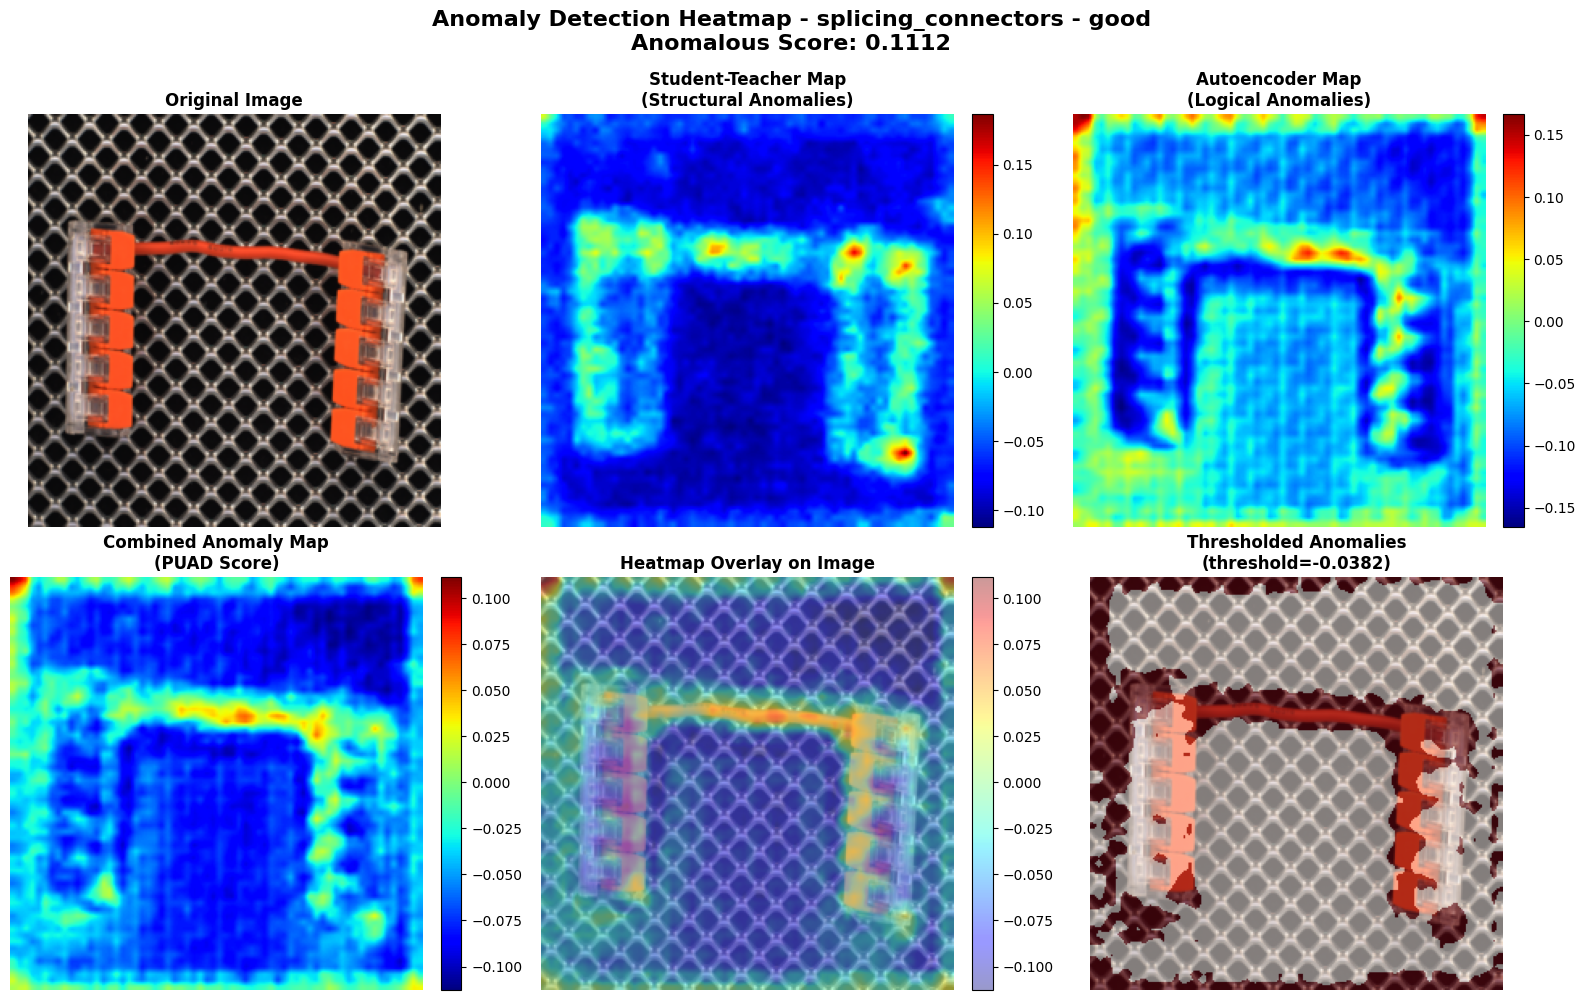


Results:
  Anomaly Score: 0.111159
  Heatmap shape: (256, 256)
  Max anomaly value: 0.111159
  Min anomaly value: -0.112742


In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import cv2

def generate_anomaly_heatmap(inference_engine, img_tensor, dataset_name, 
                             save_path=None, show_original=True):
    """
    Generate and visualize anomaly heatmap showing where anomalies are located.
    
    Args:
        inference_engine: EfficientADInference object
        img_tensor: Input image tensor [C, H, W] or [1, C, H, W]
        dataset_name: Category name for title
        save_path: Optional path to save the heatmap
        show_original: Whether to show original image alongside heatmap
    """
    
    device = inference_engine.device
    
    # Handle input dimensions
    if img_tensor.dim() == 3:
        img_tensor = img_tensor.unsqueeze(0).to(device)
    else:
        img_tensor = img_tensor.to(device)
    
    with torch.no_grad():
        # Get model outputs
        teacher_output = inference_engine.teacher(img_tensor)
        student_output = inference_engine.student(img_tensor)
        autoencoder_output = inference_engine.autoencoder(img_tensor)
        
        # Normalize teacher output
        normalized_teacher_output = (teacher_output - inference_engine.mu[None, :, None, None]) / \
                                    (inference_engine.sigma[None, :, None, None] + 1e-9)
        
        # Split student output
        student_output_st = student_output[:, :inference_engine.out_channels, :, :]
        student_output_ae = student_output[:, inference_engine.out_channels:, :, :]
        
        # Compute difference maps (local anomalies)
        map_st = torch.mean((normalized_teacher_output - student_output_st) ** 2, dim=1, keepdim=True)
        map_ae = torch.mean((autoencoder_output - student_output_ae) ** 2, dim=1, keepdim=True)
        
        # Resize to image size (256x256)
        map_st_resized = F.interpolate(map_st, size=(256, 256), mode='bilinear', align_corners=False)
        map_ae_resized = F.interpolate(map_ae, size=(256, 256), mode='bilinear', align_corners=False)
        
        #Apply quantile normalization
        map_st_normalized = 0.1 * (map_st_resized - inference_engine.q_a_student) / \
                           (inference_engine.q_b_student - inference_engine.q_a_student)
        map_ae_normalized = 0.1 * (map_ae_resized - inference_engine.q_a_autoencoder) / \
                           (inference_engine.q_b_autoencoder - inference_engine.q_a_autoencoder)
        
        #Combined anomaly map
        anomaly_map = 0.5 * map_st_normalized + 0.5 * map_ae_normalized
        
        #Get individual component maps
        anomaly_score = float(torch.max(anomaly_map).item())

        
        #Convert to numpy for visualization
        anomaly_map_np = anomaly_map.squeeze().cpu().numpy()
        map_st_np = map_st_normalized.squeeze().cpu().numpy()
        map_ae_np = map_ae_normalized.squeeze().cpu().numpy()
        
        #Denormalize original image for display
        img_display = img_tensor[0].permute(1, 2, 0).cpu().numpy()
        img_display = (img_display * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)
    
    if show_original:
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle(f'Anomaly Detection Heatmap - {dataset_name}\nAnomalous Score: {anomaly_score:.4f}',
                    fontsize=16, fontweight='bold', y=0.995)
        
        #Row 1: Original Image
        axes[0, 0].imshow(img_display)
        axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[0, 0].axis('off')
        
        #Row 1: Student-Teacher Map (Structural Anomalies)
        im1 = axes[0, 1].imshow(map_st_np, cmap='jet')
        axes[0, 1].set_title('Student-Teacher Map\n(Structural Anomalies)', fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
        plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
        
        #Row 1: Autoencoder Map (Logical Anomalies)
        im2 = axes[0, 2].imshow(map_ae_np, cmap='jet')
        axes[0, 2].set_title('Autoencoder Map\n(Logical Anomalies)', fontsize=12, fontweight='bold')
        axes[0, 2].axis('off')
        plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)
        
        #Row 2: Combined Anomaly Map
        im3 = axes[1, 0].imshow(anomaly_map_np, cmap='jet')
        axes[1, 0].set_title('Combined Anomaly Map\n(PUAD Score)', fontsize=12, fontweight='bold')
        axes[1, 0].axis('off')
        plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)
        
        #Row 2: Heatmap Overlay on Original Image
        heatmap_overlay = axes[1, 1].imshow(img_display, alpha=0.7)
        heatmap_im = axes[1, 1].imshow(anomaly_map_np, cmap='jet', alpha=0.4)
        axes[1, 1].set_title('Heatmap Overlay on Image', fontsize=12, fontweight='bold')
        axes[1, 1].axis('off')
        plt.colorbar(heatmap_im, ax=axes[1, 1], fraction=0.046, pad=0.04)
        
        #Row 2: Thresholded Anomaly Regions
        threshold = np.percentile(anomaly_map_np, 75)  # 75th percentile
        anomaly_binary = (anomaly_map_np > threshold).astype(np.uint8)
        
        axes[1, 2].imshow(img_display)
        axes[1, 2].imshow(anomaly_binary, cmap='Reds', alpha=0.5)
        axes[1, 2].set_title(f'Thresholded Anomalies\n(threshold={threshold:.4f})', 
                            fontsize=12, fontweight='bold')
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        
    else:
        #Single large heatmap view
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(f'Anomaly Heatmap - {dataset_name}\nAnomalous Score: {anomaly_score:.4f}',
                    fontsize=14, fontweight='bold')
        
        axes[0].imshow(img_display)
        axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[0].axis('off')
        
        im = axes[1].imshow(anomaly_map_np, cmap='jet')
        axes[1].set_title('Anomaly Heatmap', fontsize=12, fontweight='bold')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        
        plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Heatmap saved to {save_path}")
    
    plt.show()
    
    return {
        'anomaly_score': anomaly_score,
        'anomaly_map': anomaly_map_np,
        'student_teacher_map': map_st_np,
        'autoencoder_map': map_ae_np
    }


def batch_generate_heatmaps(inference_engine, test_dataloader, dataset_name, 
                           num_samples=5, save_dir=None):
    """
    Generate heatmaps for multiple test images.
    
    Args:
        inference_engine: EfficientADInference object
        test_dataloader: DataLoader with test images
        dataset_name: Category name
        num_samples: Number of samples to visualize
        save_dir: Directory to save heatmaps
    """
    
    from torchvision.datasets import ImageFolder
    
    count = 0
    for idx, (img, label) in enumerate(test_dataloader):
        if count >= num_samples:
            break
        
        # Get class name
        class_name = test_dataloader.dataset.classes[label.item()]
        
        save_path = None
        if save_dir:
            save_path = f"{save_dir}/heatmap_{class_name}_{idx}.png"
        
        print(f"\nGenerating heatmap {count+1}/{num_samples} - Class: {class_name}")
        
        result = generate_anomaly_heatmap(
            inference_engine=inference_engine,
            img_tensor=img.squeeze(0) if img.dim() == 4 else img,
            dataset_name=f"{dataset_name} - {class_name}",
            save_path=save_path,
            show_original=True
        )
        
        print(f"  Anomaly Score: {result['anomaly_score']:.6f}")
        count += 1

print("Generating single image heatmap...")
if len(test_dataset) > 0:
    test_img, test_label = test_dataset[19] #set the photo to check
    class_name = test_dataset.classes[test_label] if hasattr(test_dataset, 'classes') else 'unknown'
    
    result = generate_anomaly_heatmap(
        inference_engine=inference_engine,
        img_tensor=test_img,
        dataset_name=f"{dataset_name} - {class_name}",
        save_path=f"anomaly_heatmap_{dataset_name}_{class_name}.png",
        show_original=True
    )
    
    print(f"\nResults:")
    print(f"  Anomaly Score: {result['anomaly_score']:.6f}")
    print(f"  Heatmap shape: {result['anomaly_map'].shape}")
    print(f"  Max anomaly value: {result['anomaly_map'].max():.6f}")
    print(f"  Min anomaly value: {result['anomaly_map'].min():.6f}")



# 7. COMPUTATIONAL EFFICIENCY METRICS TEST

In [ ]:

print("\n" + "="*80)
print("COMPUTATIONAL EFFICIENCY ANALYSIS")
print("="*80)

import time
from torch.profiler import profile, record_function, ProfilerActivity

def calculate_flops_accurate():
    """Accurate FLOPs calculation by analyzing actual model architecture"""
    total_flops = [0]
    
    def count_conv_flops(module, input, output):
        """Count FLOPs for a convolution layer"""
        
        batch_size = input[0].shape[0]
        in_channels = module.in_channels
        out_channels = module.out_channels
        
        if isinstance(module.kernel_size, tuple):
            kernel_size = module.kernel_size[0] * module.kernel_size[1]
        else:
            kernel_size = module.kernel_size * module.kernel_size
        

        output_dims = output.shape[2:]  #h_out x w_out
        output_elements = output_dims[0] * output_dims[1]
        
        flops = 2 * in_channels * out_channels * kernel_size * output_elements * batch_size
        total_flops[0] += flops
        
    def count_linear_flops(module, input, output):
        """Count FLOPs for a linear layer"""
        if len(input[0].shape) == 2:
            batch_size = input[0].shape[0]
            input_features = input[0].shape[1]
            output_features = output.shape[1]
            flops = 2 * input_features * output_features * batch_size
            total_flops[0] += flops

    hooks = []
    models_to_profile = [
        inference_engine.teacher,
        inference_engine.student, 
        inference_engine.autoencoder
    ]
    
    for model in models_to_profile:
        for layer in model.modules():
            if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d)):
                hook = layer.register_forward_hook(count_conv_flops)
                hooks.append(hook)
            elif isinstance(layer, nn.Linear):
                hook = layer.register_forward_hook(count_linear_flops)
                hooks.append(hook)
    
    dummy_input = torch.randn(1, 3, 256, 256).to(device)
    
    with torch.no_grad():
        _ = inference_engine.teacher(dummy_input)
        _ = inference_engine.student(dummy_input) 
        _ = inference_engine.autoencoder(dummy_input)
    
    for hook in hooks:
        hook.remove()
    
    return total_flops[0]

def measure_efficiency_accurate(model_func, model_name, num_warmup=50, num_test=50):
    """Measure latency, throughput, FLOPs, parameters and GPU memory for a model"""
    
    print(f"\n--- Measuring {model_name} ---")
    
    torch.cuda.empty_cache()

    for _ in range(num_warmup):
        dummy_input = torch.randn(1, 3, 256, 256).to(device)
        _ = model_func(dummy_input)
        torch.cuda.synchronize()
    
    #measure latency (batch_size=1)
    latencies = []
    for _ in range(num_test):
        dummy_input = torch.randn(1, 3, 256, 256).to(device)
        
        torch.cuda.synchronize()
        start_time = time.time()
        _ = model_func(dummy_input)
        torch.cuda.synchronize()
        end_time = time.time()
        
        latencies.append((end_time - start_time) * 1000)  # ms
    
    avg_latency = sum(latencies) / len(latencies)
    
    batch_size = 16
    num_batches = max(1, num_test // batch_size)
    
    #create individual images
    individual_images = [torch.randn(1, 3, 256, 256).to(device) for _ in range(batch_size)]
    
    batch_times = []
    for _ in range(num_batches):
        torch.cuda.synchronize()
        start_time = time.time()
        
        for img in individual_images:
            _ = model_func(img)
        
        torch.cuda.synchronize()
        end_time = time.time()
        
        batch_times.append(end_time - start_time)
    
    total_time = sum(batch_times) if batch_times else 1.0
    throughput = (num_batches * batch_size) / total_time
    
    total_params = (sum(p.numel() for p in inference_engine.teacher.parameters()) +
                   sum(p.numel() for p in inference_engine.student.parameters()) +
                   sum(p.numel() for p in inference_engine.autoencoder.parameters()))
    
    #flops calcu
    print("Calculating accurate FLOPs...")
    try:
        total_flops = calculate_flops_accurate()
        print(f"Accurate FLOPs calculation successful: {total_flops / 1e9:.1f}B")
    except Exception as e:
        print(f"Accurate FLOPs failed: {e}")

        dummy_input = torch.randn(1, 3, 256, 256).to(device)
        with profile(activities=[ProfilerActivity.CUDA], with_flops=True) as prof:
            _ = model_func(dummy_input)
        total_flops = sum([event.flops for event in prof.key_averages() if event.flops > 0])
    
    #mem usage
    memory_stats = torch.cuda.memory_stats()
    peak_memory = memory_stats.get('allocated_bytes.all.peak', 0) / (1024 * 1024)
    
    return {
        'latency_ms': avg_latency,
        'throughput_img_s': throughput,
        'parameters_millions': total_params / 1e6,
        'flops_billions': total_flops / 1e9,
        'gpu_memory_mb': peak_memory
    }

def efficientad_wrapper(img_tensor):
    with torch.inference_mode():  
        if img_tensor.dim() == 3:
            img_tensor = img_tensor.unsqueeze(0)
        return inference_engine.run(img_tensor, is_for_puad=True)

def puad_wrapper(img_tensor):
    with torch.inference_mode():  
        if img_tensor.dim() == 3:
            img_tensor = img_tensor.unsqueeze(0)
        return puad_model.test(img_tensor)
    
print("Starting accurate measurements...")

effad_metrics = measure_efficiency_accurate(efficientad_wrapper, "EfficientAD") 
puad_metrics = measure_efficiency_accurate(puad_wrapper, "PUAD") 

print("\n" + "="*80)
print("RESULTS SUMMARY - ACCURATE FLOPs")
print("="*80)
print(f"{'Metric':<25} {'EfficientAD':<15} {'PUAD':<15}")
print("-" * 55)
print(f"{'Detection AU-ROC':<25} {efficientad_auroc:<15.3f} {puad_auroc:<15.3f}")
print(f"{'Latency (ms)':<25} {effad_metrics['latency_ms']:<15.1f} {puad_metrics['latency_ms']:<15.1f}")
print(f"{'Throughput (img/s)':<25} {effad_metrics['throughput_img_s']:<15.0f} {puad_metrics['throughput_img_s']:<15.0f}")
print(f"{'Parameters (M)':<25} {effad_metrics['parameters_millions']:<15.1f} {puad_metrics['parameters_millions']:<15.1f}")
print(f"{'FLOPs (B)':<25} {effad_metrics['flops_billions']:<15.1f} {puad_metrics['flops_billions']:<15.1f}")
print(f"{'GPU Memory (MB)':<25} {effad_metrics['gpu_memory_mb']:<15.0f} {puad_metrics['gpu_memory_mb']:<15.0f}")

print("\n" + "="*80)
print("PERFORMANCE ANALYSIS")
print("="*80)
print(f"PUAD vs EfficientAD Performance Ratio:")
print(f"- Latency: {puad_metrics['latency_ms'] / effad_metrics['latency_ms']:.1f}x")
print(f"- Throughput: {effad_metrics['throughput_img_s'] / puad_metrics['throughput_img_s']:.1f}x") 
print(f"- FLOPs: {puad_metrics['flops_billions'] / effad_metrics['flops_billions']:.1f}x")
print(f"- AU-ROC Improvement: {(puad_auroc - efficientad_auroc) / efficientad_auroc * 100:.1f}%")

print("\n" + "="*80)
print("COMPARISON WITH PAPER RESULTS (EfficientAD-S)")
print("="*80)
print(f"{'Metric':<25} {'Your Results':<15} {'Paper Results':<15} {'Ratio':<10}")
print("-" * 65)
print(f"{'Latency (ms)':<25} {effad_metrics['latency_ms']:<15.1f} {'2.2':<15} {effad_metrics['latency_ms'] / 2.2:.1f}x")
print(f"{'Throughput (img/s)':<25} {effad_metrics['throughput_img_s']:<15.0f} {'614':<15} {614 / effad_metrics['throughput_img_s']:.1f}x")
print(f"{'Parameters (M)':<25} {effad_metrics['parameters_millions']:<15.1f} {'8':<15} {effad_metrics['parameters_millions'] / 8:.1f}x")
print(f"{'FLOPs (B)':<25} {effad_metrics['flops_billions']:<15.1f} {'76':<15} {effad_metrics['flops_billions'] / 76:.1f}x")
print(f"{'GPU Memory (MB)':<25} {effad_metrics['gpu_memory_mb']:<15.0f} {'100':<15} {effad_metrics['gpu_memory_mb'] / 100:.1f}x")


COMPUTATIONAL EFFICIENCY ANALYSIS
Starting accurate measurements...

--- Measuring EfficientAD ---
Calculating accurate FLOPs...
Accurate FLOPs calculation successful: 93.1B

--- Measuring PUAD ---
Calculating accurate FLOPs...
Accurate FLOPs calculation successful: 93.1B

RESULTS SUMMARY - ACCURATE FLOPs
Metric                    EfficientAD     PUAD           
-------------------------------------------------------
Detection AU-ROC          0.852           0.941          
Latency (ms)              7.7             8.0            
Throughput (img/s)        125             124            
Parameters (M)            8.1             8.1            
FLOPs (B)                 93.1            93.1           
GPU Memory (MB)           3185            3185           

PERFORMANCE ANALYSIS
PUAD vs EfficientAD Performance Ratio:
- Latency: 1.0x
- Throughput: 1.0x
- FLOPs: 1.0x
- AU-ROC Improvement: 10.5%

COMPARISON WITH PAPER RESULTS (EfficientAD-S)
Metric                    Your Results    Pap